# Data Mining — Superstore Dataset

Notebook ini fokus pada **pemodelan data mining**:

1. **Customer Behaviour Clustering** — segmentasi pelanggan berdasarkan perilaku belanja (KMeans & DBSCAN)
2. **Association Rule Mining** — asosiasi antar Sub-Category (Apriori, FP-Growth, ECLAT)
3. **Segmented Association Rule Mining** — gabungan keduanya: rule ditambang per segmen pelanggan

EDA hanya disajikan seperlunya di sini. **EDA lengkap ada di `EDA.ipynb`.**

Sumber dataset: Kaggle — "Superstore Dataset" ([link](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)).

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Data

In [2]:
df = pd.read_csv('Superstore.csv', encoding="latin1")

## 3. EDA Singkat

Ringkasan struktur data secukupnya untuk keperluan pemodelan. Analisis mendalam ada di `EDA.ipynb`.

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.shape

(9994, 21)

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
# Cek missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

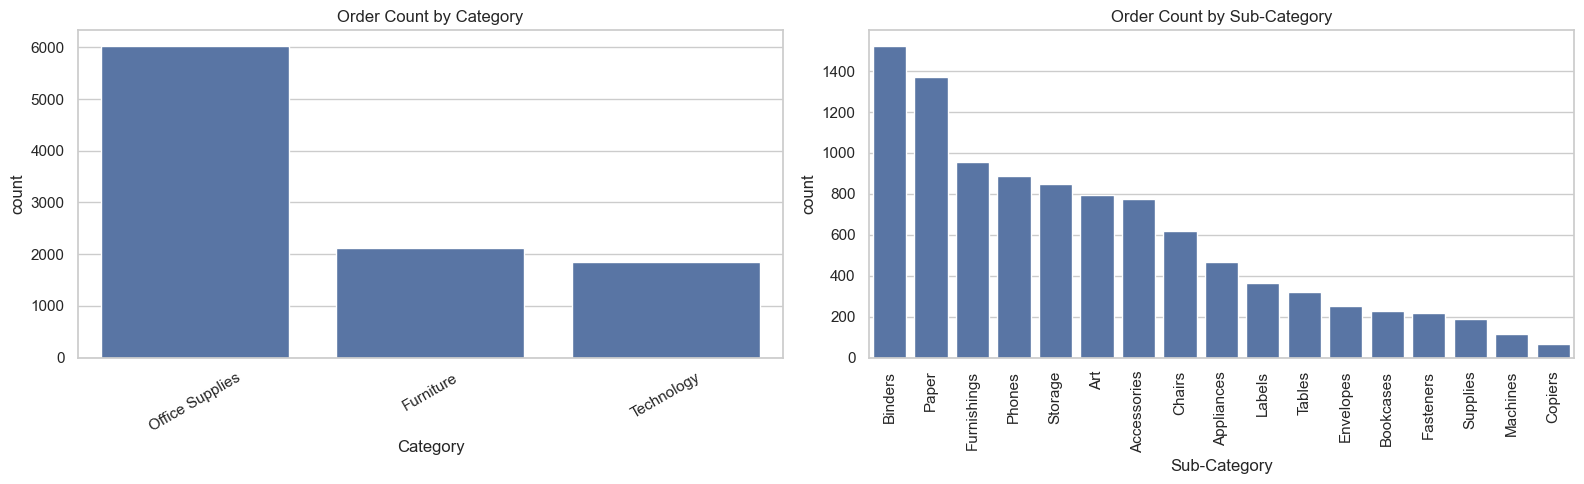

In [8]:
# Distribusi order per Category & Sub-Category (konteks untuk Association Rule Mining)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, ax=axes[0])
axes[0].set_title('Order Count by Category')
axes[0].tick_params(axis='x', rotation=30)
sns.countplot(data=df, x='Sub-Category', order=df['Sub-Category'].value_counts().index, ax=axes[1])
axes[1].set_title('Order Count by Sub-Category')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 4. Persiapan Data

In [9]:
# Hapus transaksi duplikat (Product ID ganda dalam satu Order ID dengan Quantity berbeda)
print("Duplikat sebelum:", df.duplicated(subset=["Order ID", "Product ID", "Order Date"], keep=False).sum())
df = df.drop_duplicates(subset=["Order ID", "Product ID", "Order Date"], keep=False)

# Konversi tipe data tanggal
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Hilangkan kolom yang tidak diperlukan
df.drop(columns=["Row ID"], inplace=True)
df.info()

Duplikat sebelum: 16
<class 'pandas.core.frame.DataFrame'>
Index: 9978 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9978 non-null   object        
 1   Order Date     9978 non-null   datetime64[ns]
 2   Ship Date      9978 non-null   datetime64[ns]
 3   Ship Mode      9978 non-null   object        
 4   Customer ID    9978 non-null   object        
 5   Customer Name  9978 non-null   object        
 6   Segment        9978 non-null   object        
 7   Country        9978 non-null   object        
 8   City           9978 non-null   object        
 9   State          9978 non-null   object        
 10  Postal Code    9978 non-null   int64         
 11  Region         9978 non-null   object        
 12  Product ID     9978 non-null   object        
 13  Category       9978 non-null   object        
 14  Sub-Category   9978 non-null   object        
 15  Produ

## 5. Customer Behaviour Clustering

Segmentasi pelanggan berdasarkan perilaku belanja. Hasil cluster ini dipakai kembali di
**Bagian 8** untuk menambang association rule per segmen.

Agregasi transaksi per `Customer ID` menjadi fitur: total Sales, total Quantity,
rata-rata Discount, jumlah order, dan total Profit.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [11]:
df_customers = (df.groupby("Customer ID")[['Sales', 'Quantity', 'Discount', 'Order ID', 'Profit']]
    .agg({'Sales': 'sum', 'Quantity': 'sum', 'Discount': 'mean', 'Order ID': 'count', 'Profit': 'sum'})
    .reset_index())
df_customers.head()

,Customer ID,Sales,Quantity,Discount,Order ID,Profit
0,AA-10315,5563.560,30,0.090909,11,-362.8825
1,AA-10375,1056.390,41,0.080000,15,277.3824
2,AA-10480,1790.512,36,0.016667,12,435.8274
3,AA-10645,5086.935,64,0.063889,18,857.8033
4,AB-10015,886.156,13,0.066667,6,129.3465


In [12]:
df_customers.describe()

,Sales,Quantity,Discount,Order ID,Profit
count,793.000000,793.000000,793.000000,793.000000,793.000000
mean,2890.362414,47.648172,0.157555,12.582598,359.493317
std,2624.162617,24.716495,0.089099,6.218541,893.183179
min,4.833000,2.000000,0.000000,1.000000,-6626.389500
25%,1146.050000,30.000000,0.090909,8.000000,35.486500
50%,2254.285000,44.000000,0.150000,12.000000,227.438400
75%,3766.382000,63.000000,0.211111,16.000000,560.007800
max,25043.050000,150.000000,0.700000,37.000000,8981.323900


In [13]:
features = df_customers[['Sales', 'Quantity', 'Discount', 'Order ID', 'Profit']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### DBSCAN

DBSCAN_Cluster
 0    494
-1    281
 2      6
 3      6
 1      6
Name: count, dtype: int64


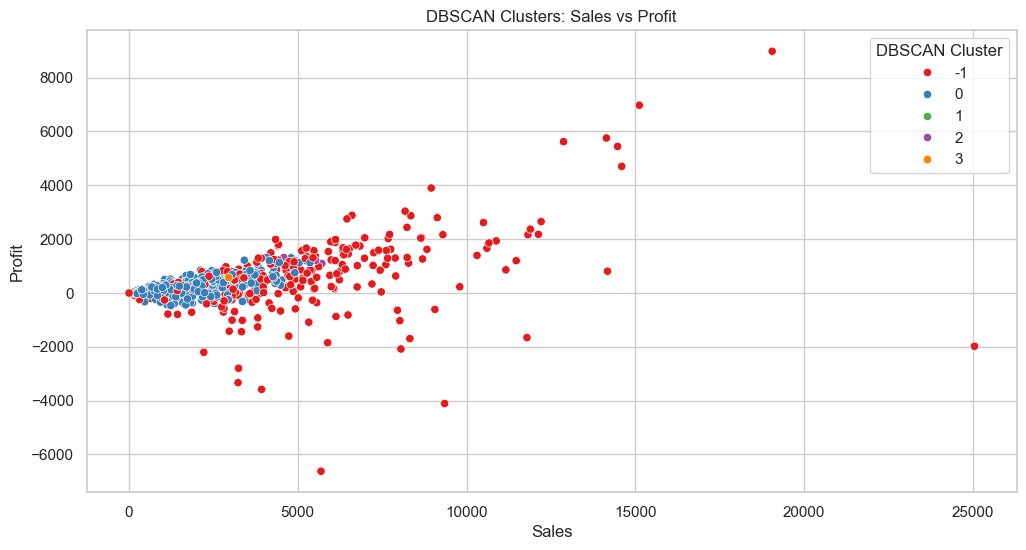

In [14]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(scaled_features)

df_customers['DBSCAN_Cluster'] = dbscan.labels_
print(df_customers['DBSCAN_Cluster'].value_counts())

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_customers, x='Sales', y='Profit', hue='DBSCAN_Cluster', palette='Set1')
plt.title('DBSCAN Clusters: Sales vs Profit')
plt.legend(title='DBSCAN Cluster')
plt.show()

In [15]:
df_customers.groupby('DBSCAN_Cluster')[['Sales', 'Quantity', 'Discount', 'Order ID', 'Profit']].mean()

,Sales,Quantity,Discount,Order ID,Profit
DBSCAN_Cluster,,,,,
-1,4910.772270,64.291815,0.182105,16.451957,583.262765
0,1717.962041,37.222672,0.145870,10.107287,219.681738
1,2566.791800,72.000000,0.163882,20.000000,306.850883
2,5155.810333,79.333333,0.071331,21.166667,1176.822933
3,2853.587500,70.500000,0.049803,19.166667,626.090300


### KMeans

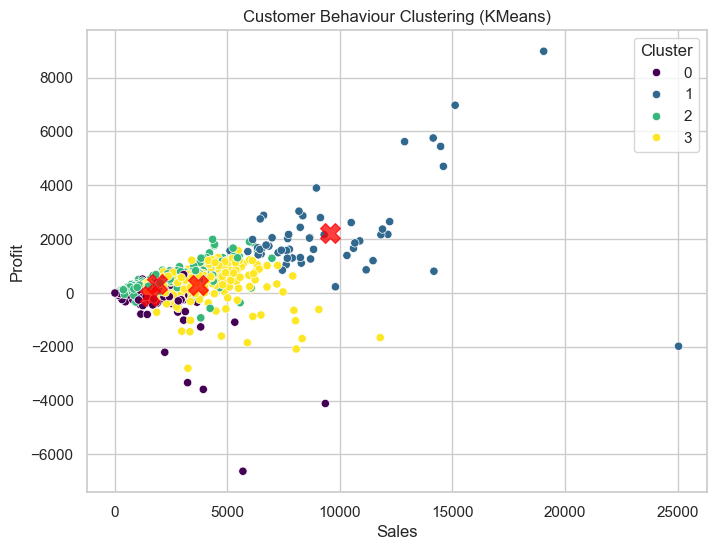

In [16]:
kmeans = KMeans(n_clusters=4, random_state=7, n_init=10)
kmeans.fit(scaled_features)
df_customers['Cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sales', y='Profit', hue='Cluster', data=df_customers, palette='viridis', legend='full')
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 4], c='red', s=200, alpha=0.75, marker='X')
plt.title('Customer Behaviour Clustering (KMeans)')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend(title='Cluster', loc='upper right')
plt.show()

In [17]:
score = silhouette_score(scaled_features, kmeans.labels_)
print(f'Silhouette Score untuk {kmeans.n_clusters} cluster: {score:.4f}')

Silhouette Score untuk 4 cluster: 0.2725


In [18]:
df_customers.groupby('Cluster')[['Sales', 'Quantity', 'Discount', 'Order ID', 'Profit']].mean()

,Sales,Quantity,Discount,Order ID,Profit
Cluster,,,,,
0,1544.220445,30.897849,0.260414,8.284946,-99.313371
1,9553.287242,77.290909,0.123491,19.727273,2237.993698
2,1883.364331,33.889610,0.095275,9.230519,339.778911
3,3685.759752,71.102459,0.165439,18.479508,310.692333


## 6. Association Rule Mining

Karena jumlah produk sangat banyak, kita menggunakan **Sub-Category** sebagai *item*. Setiap
*transaksi* adalah kumpulan Sub-Category unik dalam satu `Order ID`. Digunakan tiga algoritma
*frequent itemset mining*: **Apriori**, **FP-Growth**, dan **ECLAT**.

In [19]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

df_orders_subcategory = df[['Order ID', 'Sub-Category']].copy()
df_orders_subcategory['Sub-Category'].value_counts()

Sub-Category
Binders        1521
Paper          1366
Furnishings     955
Phones          889
Storage         844
Art             796
Accessories     771
Chairs          615
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [20]:
transactions = (df_orders_subcategory.groupby('Order ID')['Sub-Category']
    .apply(lambda x: list(set(x)))  # hilangkan duplikat dalam satu order
    .tolist())

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

MIN_SUPPORT = 0.001
MIN_CONFIDENCE = 0.7
print("Jumlah transaksi:", len(transactions), "| Jumlah item unik:", df_encoded.shape[1])


def format_rules(rules):
    """Rapikan output association_rules + urutkan konsisten agar bisa dibandingkan antar algoritma."""
    out = rules.copy()
    out['antecedents'] = out['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    out['consequents'] = out['consequents'].apply(lambda x: ', '.join(sorted(x)))
    out = out[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    return out.sort_values(['antecedents', 'consequents']).round(4).reset_index(drop=True)

Jumlah transaksi: 5007 | Jumlah item unik: 17


### 6.1 Apriori

In [21]:
t0 = time.perf_counter()
frequent_itemsets_ap = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
rules_ap = association_rules(frequent_itemsets_ap, metric="confidence", min_threshold=MIN_CONFIDENCE)
time_ap = time.perf_counter() - t0

rules_ap_fmt = format_rules(rules_ap)
print(f"Apriori: {len(frequent_itemsets_ap)} itemsets, {len(rules_ap_fmt)} rules, {time_ap:.3f}s")
display(rules_ap_fmt)

Apriori: 514 itemsets, 11 rules, 0.045s


,antecedents,consequents,support,confidence,lift
0,"Accessories, Appliances, Chairs",Binders,0.0012,0.7500,2.8557
1,"Accessories, Appliances, Furnishings",Binders,0.0018,0.7500,2.8557
2,"Accessories, Furnishings, Tables",Paper,0.0014,0.7778,3.2753
3,"Appliances, Chairs, Furnishings",Binders,0.0016,0.7273,2.7692
4,"Appliances, Furnishings, Storage",Binders,0.0024,0.7059,2.6877
5,"Appliances, Furnishings, Tables",Phones,0.0014,0.7000,4.3058
6,"Appliances, Phones, Tables",Furnishings,0.0014,0.7000,4.0010
7,"Art, Fasteners, Phones",Binders,0.0012,0.7500,2.8557
8,"Chairs, Copiers",Paper,0.0016,0.8000,3.3689
9,"Fasteners, Phones, Storage",Binders,0.0014,0.7000,2.6653


### 6.2 FP-Growth

In [22]:
t0 = time.perf_counter()
frequent_itemsets_fp = fpgrowth(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=MIN_CONFIDENCE)
time_fp = time.perf_counter() - t0

rules_fp_fmt = format_rules(rules_fp)
print(f"FP-Growth: {len(frequent_itemsets_fp)} itemsets, {len(rules_fp_fmt)} rules, {time_fp:.3f}s")
display(rules_fp_fmt)

FP-Growth: 514 itemsets, 11 rules, 4.479s


,antecedents,consequents,support,confidence,lift
0,"Accessories, Appliances, Chairs",Binders,0.0012,0.7500,2.8557
1,"Accessories, Appliances, Furnishings",Binders,0.0018,0.7500,2.8557
2,"Accessories, Furnishings, Tables",Paper,0.0014,0.7778,3.2753
3,"Appliances, Chairs, Furnishings",Binders,0.0016,0.7273,2.7692
4,"Appliances, Furnishings, Storage",Binders,0.0024,0.7059,2.6877
5,"Appliances, Furnishings, Tables",Phones,0.0014,0.7000,4.3058
6,"Appliances, Phones, Tables",Furnishings,0.0014,0.7000,4.0010
7,"Art, Fasteners, Phones",Binders,0.0012,0.7500,2.8557
8,"Chairs, Copiers",Paper,0.0016,0.8000,3.3689
9,"Fasteners, Phones, Storage",Binders,0.0014,0.7000,2.6653


### 6.3 ECLAT

`mlxtend` tidak menyediakan ECLAT, jadi kita implementasikan sendiri. ECLAT memakai **format
data vertikal**: tiap item dipetakan ke *tidset* (himpunan id transaksi yang memuatnya).
Support sebuah itemset = ukuran irisan tidset anggotanya, dan kandidat dibangun secara
*depth-first* dengan meng-irisan tidset — tanpa memindai ulang database.

In [23]:
def eclat(df_encoded, min_support=0.001):
    """Frequent itemset mining ala ECLAT (vertical tidset intersection)."""
    n = len(df_encoded)
    tidsets = {frozenset([c]): set(df_encoded.index[df_encoded[c].values])
               for c in df_encoded.columns}
    freq = {k: v for k, v in tidsets.items() if len(v) / n >= min_support}

    current = list(freq.items())
    while current:
        next_level = []
        for i in range(len(current)):
            for j in range(i + 1, len(current)):
                a, ta = current[i]
                b, tb = current[j]
                union = a | b
                if len(union) != len(a) + 1 or union in freq:
                    continue
                inter = ta & tb
                if len(inter) / n >= min_support:
                    freq[union] = inter
                    next_level.append((union, inter))
        current = next_level

    rows = [{'support': len(t) / n, 'itemsets': iset} for iset, t in freq.items()]
    return (pd.DataFrame(rows)
            .sort_values('support', ascending=False)
            .reset_index(drop=True))


t0 = time.perf_counter()
frequent_itemsets_ec = eclat(df_encoded, min_support=MIN_SUPPORT)
rules_ec = association_rules(frequent_itemsets_ec, metric="confidence", min_threshold=MIN_CONFIDENCE)
time_ec = time.perf_counter() - t0

rules_ec_fmt = format_rules(rules_ec)
print(f"ECLAT: {len(frequent_itemsets_ec)} itemsets, {len(rules_ec_fmt)} rules, {time_ec:.3f}s")
display(rules_ec_fmt)

ECLAT: 514 itemsets, 11 rules, 0.022s


,antecedents,consequents,support,confidence,lift
0,"Accessories, Appliances, Chairs",Binders,0.0012,0.7500,2.8557
1,"Accessories, Appliances, Furnishings",Binders,0.0018,0.7500,2.8557
2,"Accessories, Furnishings, Tables",Paper,0.0014,0.7778,3.2753
3,"Appliances, Chairs, Furnishings",Binders,0.0016,0.7273,2.7692
4,"Appliances, Furnishings, Storage",Binders,0.0024,0.7059,2.6877
5,"Appliances, Furnishings, Tables",Phones,0.0014,0.7000,4.3058
6,"Appliances, Phones, Tables",Furnishings,0.0014,0.7000,4.0010
7,"Art, Fasteners, Phones",Binders,0.0012,0.7500,2.8557
8,"Chairs, Copiers",Paper,0.0016,0.8000,3.3689
9,"Fasteners, Phones, Storage",Binders,0.0014,0.7000,2.6653


### 6.4 Perbandingan Algoritma

,Algoritma,Frequent Itemsets,Rules,Waktu (detik)
0,Apriori,514,11,0.045492
1,FP-Growth,514,11,4.478615
2,ECLAT,514,11,0.021979


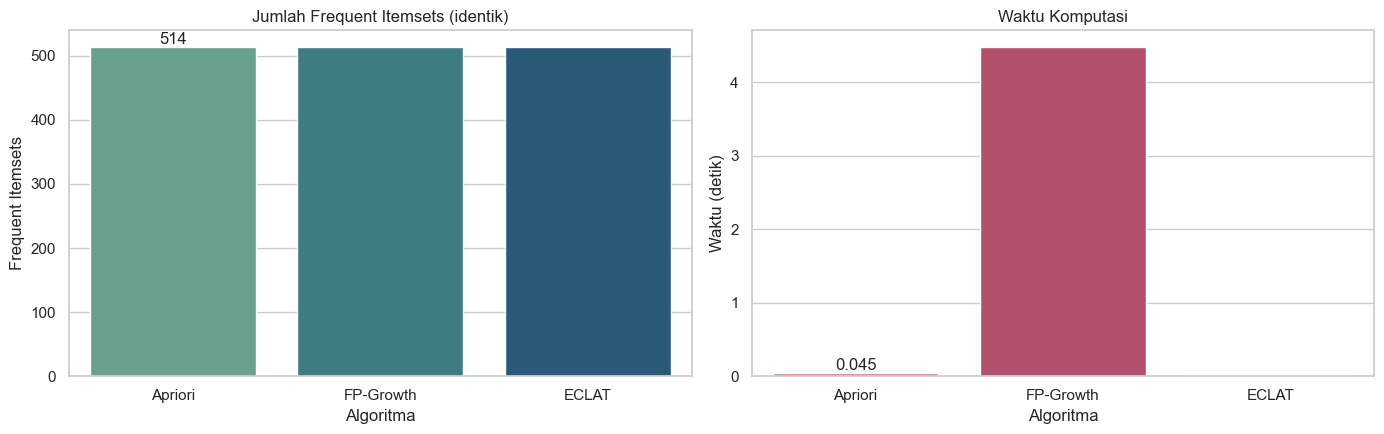

In [24]:
comparison = pd.DataFrame({
    'Algoritma': ['Apriori', 'FP-Growth', 'ECLAT'],
    'Frequent Itemsets': [len(frequent_itemsets_ap), len(frequent_itemsets_fp), len(frequent_itemsets_ec)],
    'Rules': [len(rules_ap), len(rules_fp), len(rules_ec)],
    'Waktu (detik)': [time_ap, time_fp, time_ec],
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=comparison, x='Algoritma', y='Frequent Itemsets', hue='Algoritma',
            palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Jumlah Frequent Itemsets (identik)')
axes[0].bar_label(axes[0].containers[0])
sns.barplot(data=comparison, x='Algoritma', y='Waktu (detik)', hue='Algoritma',
            palette='flare', legend=False, ax=axes[1])
axes[1].set_title('Waktu Komputasi')
axes[1].bar_label(axes[1].containers[0], fmt='%.3f')
plt.tight_layout()
plt.show()

In [25]:
# Verifikasi: apakah rule dari 6.1, 6.2, 6.3 benar-benar identik?
print("Apriori == FP-Growth :", rules_ap_fmt.equals(rules_fp_fmt))
print("Apriori == ECLAT     :", rules_ap_fmt.equals(rules_ec_fmt))

Apriori == FP-Growth : True
Apriori == ECLAT     : True


Ketiga algoritma (6.1-6.3) menghasilkan **frequent itemset dan rule yang identik** — perbedaannya
hanya pada strategi pencarian, bukan hasil. Waktu komputasi bergantung pada implementasi
masing-masing (mis. FP-Growth `mlxtend` menanggung overhead pembentukan FP-tree yang besar saat
`min_support` sangat kecil seperti 0.001), sehingga bukan tolok ukur mutlak keunggulan algoritma.

### 6.5 Association Rules (untuk analisis lanjutan)

Karena hasil ketiga algoritma identik, analisis & visualisasi selanjutnya (bagian 7 & 8)
memakai **FP-Growth** sebagai algoritma acuan.

In [26]:
rules = (rules_fp_fmt.sort_values('confidence', ascending=False).reset_index(drop=True))
rules['rule'] = rules['antecedents'] + '  ->  ' + rules['consequents']
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

,antecedents,consequents,support,confidence,lift
0,"Chairs, Copiers",Paper,0.0016,0.8000,3.3689
1,"Accessories, Furnishings, Tables",Paper,0.0014,0.7778,3.2753
2,"Accessories, Appliances, Chairs",Binders,0.0012,0.7500,2.8557
3,"Accessories, Appliances, Furnishings",Binders,0.0018,0.7500,2.8557
4,"Art, Fasteners, Phones",Binders,0.0012,0.7500,2.8557
5,"Appliances, Chairs, Furnishings",Binders,0.0016,0.7273,2.7692
6,"Appliances, Furnishings, Storage",Binders,0.0024,0.7059,2.6877
7,"Appliances, Furnishings, Tables",Phones,0.0014,0.7000,4.3058
8,"Appliances, Phones, Tables",Furnishings,0.0014,0.7000,4.0010
9,"Fasteners, Phones, Storage",Binders,0.0014,0.7000,2.6653


## 7. Visualisasi Hasil Association Rule Mining

### 7.1 Support vs Confidence (ukuran & warna = lift)

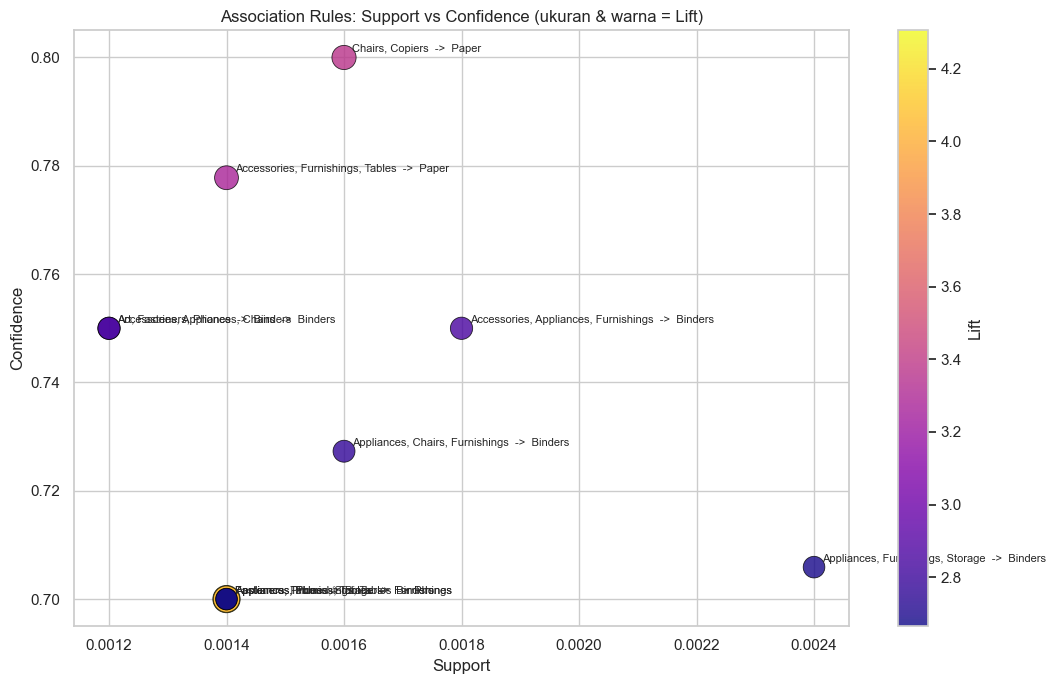

In [27]:
plt.figure(figsize=(11, 7))
sc = plt.scatter(rules['support'], rules['confidence'],
                 s=rules['lift'] * 90, c=rules['lift'],
                 cmap='plasma', alpha=0.8, edgecolors='black', linewidths=0.6)
plt.colorbar(sc, label='Lift')
for _, r in rules.iterrows():
    plt.annotate(r['rule'], (r['support'], r['confidence']),
                 fontsize=8, xytext=(6, 4), textcoords='offset points')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (ukuran & warna = Lift)')
plt.tight_layout()
plt.show()

### 7.2 Top Rules berdasarkan Lift

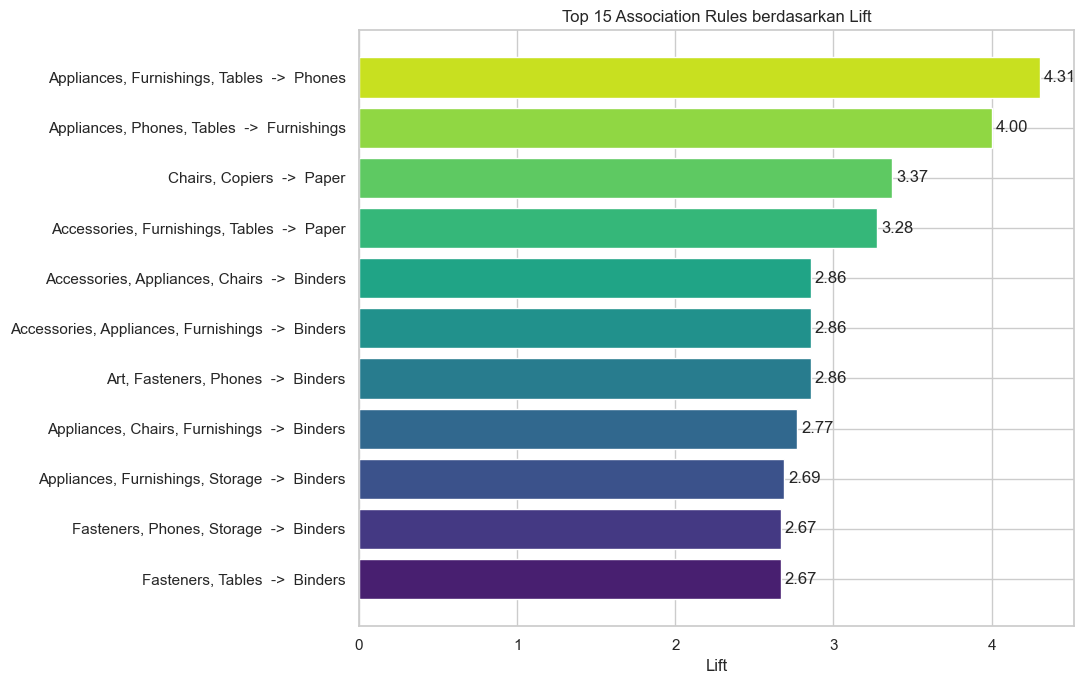

In [28]:
top = rules.sort_values('lift', ascending=False).head(15).iloc[::-1]

plt.figure(figsize=(11, 7))
bars = plt.barh(top['rule'], top['lift'], color=sns.color_palette('viridis', len(top)))
plt.bar_label(bars, fmt='%.2f', padding=3)
plt.xlabel('Lift')
plt.title('Top 15 Association Rules berdasarkan Lift')
plt.tight_layout()
plt.show()

### 7.3 Heatmap Antecedent x Consequent

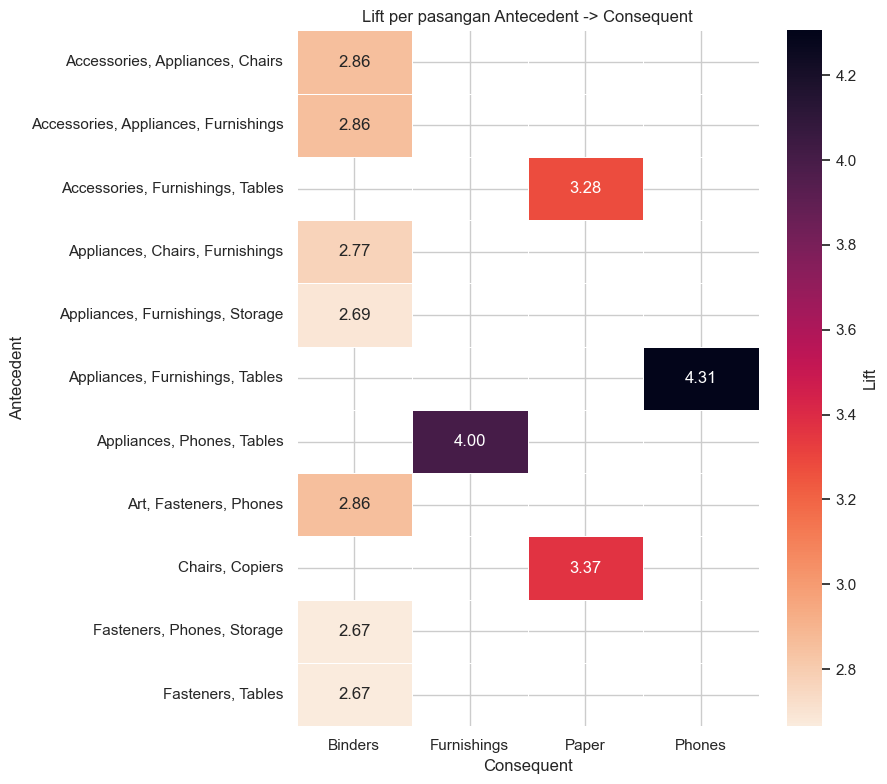

In [29]:
pivot = (rules.assign(consequents=rules['consequents'])
         .pivot_table(index='antecedents', columns='consequents', values='lift'))

plt.figure(figsize=(9, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='rocket_r', linewidths=0.5,
            cbar_kws={'label': 'Lift'})
plt.title('Lift per pasangan Antecedent -> Consequent')
plt.xlabel('Consequent')
plt.ylabel('Antecedent')
plt.tight_layout()
plt.show()

### 7.4 Network Graph Rule

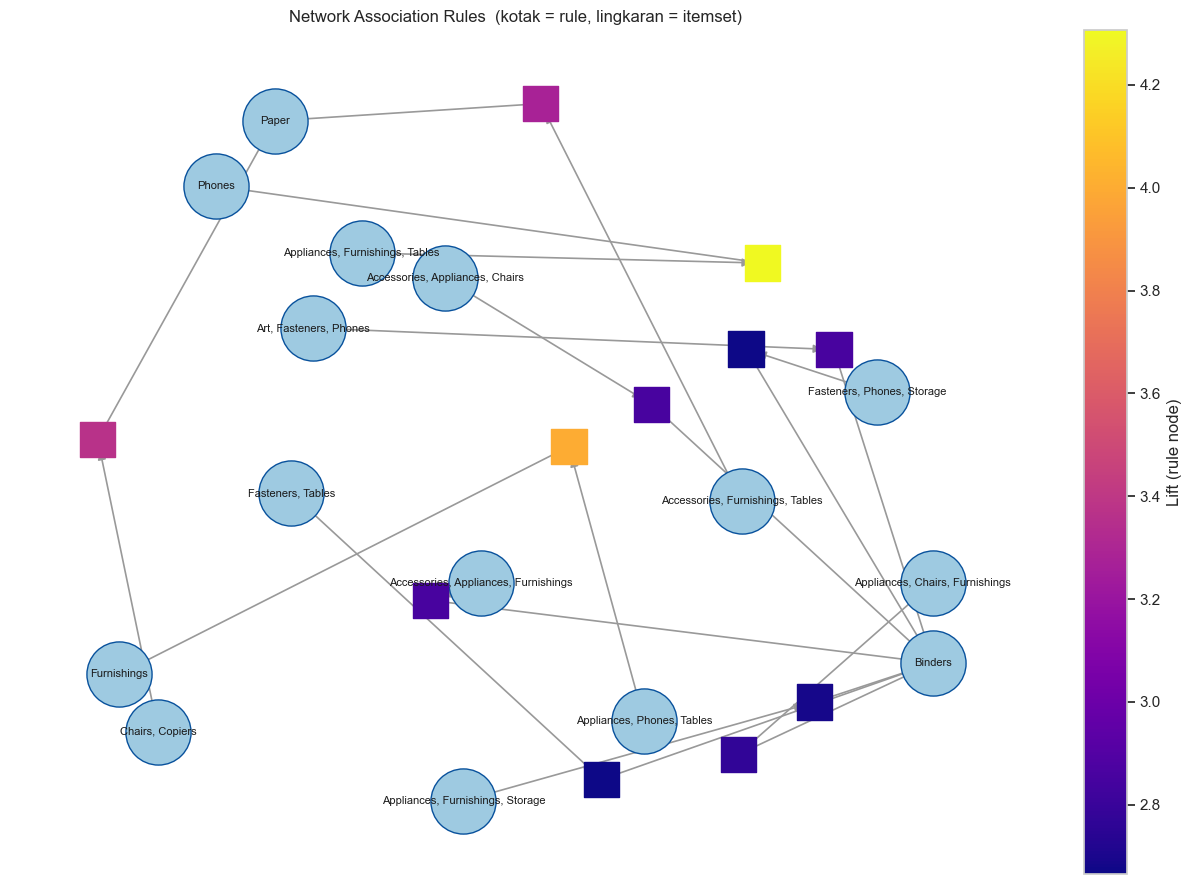

In [30]:
import networkx as nx

rules_raw = association_rules(frequent_itemsets_fp, metric="confidence",
                              min_threshold=MIN_CONFIDENCE).sort_values('lift', ascending=False)

G = nx.DiGraph()
for _, r in rules_raw.iterrows():
    ant = ', '.join(sorted(r['antecedents']))
    con = ', '.join(sorted(r['consequents']))
    rule_node = f"R{len(G):02d}"
    G.add_node(ant, kind='item')
    G.add_node(con, kind='item')
    G.add_node(rule_node, kind='rule', lift=r['lift'], confidence=r['confidence'])
    G.add_edge(ant, rule_node)
    G.add_edge(rule_node, con)

pos = nx.spring_layout(G, k=0.9, seed=7)
item_nodes = [n for n, d in G.nodes(data=True) if d['kind'] == 'item']
rule_nodes = [n for n, d in G.nodes(data=True) if d['kind'] == 'rule']
rule_lift = [G.nodes[n]['lift'] for n in rule_nodes]

plt.figure(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, edge_color='#999999', arrowsize=12, width=1.2)
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_color='#9ecae1',
                       node_size=2200, edgecolors='#08519c')
nodes = nx.draw_networkx_nodes(G, pos, nodelist=rule_nodes, node_color=rule_lift,
                               cmap='plasma', node_size=650, node_shape='s')
nx.draw_networkx_labels(G, pos, labels={n: n for n in item_nodes}, font_size=8)
plt.colorbar(nodes, label='Lift (rule node)')
plt.title('Network Association Rules  (kotak = rule, lingkaran = itemset)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Segmented Association Rule Mining (Clustering -> Rule-Based)

Bagian 6-7 sudah menambang rule untuk **seluruh** pelanggan (tanpa segmentasi). Di sini kita
gabungkan kedua teknik: setiap transaksi diberi label **cluster perilaku customer** (hasil KMeans
di bagian 5), lalu Association Rule Mining dijalankan **per segmen**. Tujuannya melihat apakah
pola *cross-sell* berbeda antar tipe pelanggan.

### 8.1 Beri label segmen ke setiap transaksi

In [31]:
# Profil tiap cluster + urutkan berdasarkan rata-rata Sales untuk memberi nama tier
profile = (df_customers.groupby('Cluster')[['Sales', 'Quantity', 'Discount', 'Order ID', 'Profit']]
           .mean()
           .assign(n_customers=df_customers['Cluster'].value_counts()))

tier_names = ['Low-value', 'Mid-value', 'Upper-mid', 'High-value']
ordered = profile.sort_values('Sales').index.tolist()
cluster_label = {cl: f"S{rank} - {tier_names[rank]}" for rank, cl in enumerate(ordered)}
# Tandai segmen yang rata-rata profitnya negatif
for cl in profile.index:
    if profile.loc[cl, 'Profit'] < 0:
        cluster_label[cl] += " (unprofitable)"

profile['Segment'] = profile.index.map(cluster_label)
display(profile[['Segment', 'n_customers', 'Sales', 'Order ID', 'Discount', 'Profit']]
        .rename(columns={'Order ID': 'Orders/cust'}).sort_values('Sales'))

# Map Customer ID -> cluster -> label, tempelkan ke transaksi
cust_to_cluster = df_customers.set_index('Customer ID')['Cluster']
df['Segment'] = df['Customer ID'].map(cust_to_cluster).map(cluster_label)
df[['Order ID', 'Customer ID', 'Segment', 'Sub-Category']].head()

,Segment,n_customers,Sales,Orders/cust,Discount,Profit
Cluster,,,,,,
0,S0 - Low-value (unprofitable),186,1544.220445,8.284946,0.260414,-99.313371
2,S1 - Mid-value,308,1883.364331,9.230519,0.095275,339.778911
3,S2 - Upper-mid,244,3685.759752,18.479508,0.165439,310.692333
1,S3 - High-value,55,9553.287242,19.727273,0.123491,2237.993698


,Order ID,Customer ID,Segment,Sub-Category
0,CA-2016-152156,CG-12520,S0 - Low-value (unprofitable),Bookcases
1,CA-2016-152156,CG-12520,S0 - Low-value (unprofitable),Chairs
2,CA-2016-138688,DV-13045,S0 - Low-value (unprofitable),Labels
3,US-2015-108966,SO-20335,S2 - Upper-mid,Tables
4,US-2015-108966,SO-20335,S2 - Upper-mid,Storage


### 8.2 Jalankan FP-Growth per segmen

Setiap segmen memakai ambang batas yang **sama** (support >= 0.005, confidence >= 0.4, lift >= 1)
supaya jumlah & kekuatan rule antar segmen bisa dibandingkan langsung.

In [32]:
def mine_rules(frame, min_support=0.005, min_confidence=0.4, min_lift=1.0):
    """Bangun transaksi Sub-Category dari `frame` lalu tambang association rules (FP-Growth)."""
    tx = (frame.groupby('Order ID')['Sub-Category']
          .apply(lambda x: list(set(x))).tolist())
    te_ = TransactionEncoder()
    enc_ = pd.DataFrame(te_.fit(tx).transform(tx), columns=te_.columns_)
    fi_ = fpgrowth(enc_, min_support=min_support, use_colnames=True)
    r_ = association_rules(fi_, metric='confidence', min_threshold=min_confidence)
    r_ = r_[r_['lift'] >= min_lift].copy()
    r_['antecedents'] = r_['antecedents'].apply(lambda s: ', '.join(sorted(s)))
    r_['consequents'] = r_['consequents'].apply(lambda s: ', '.join(sorted(s)))
    r_['rule'] = r_['antecedents'] + '  ->  ' + r_['consequents']
    return r_.sort_values('lift', ascending=False).reset_index(drop=True), len(tx)


segment_rules = {}
summary_rows = []
for seg in sorted(df['Segment'].dropna().unique()):
    r_seg, n_tx = mine_rules(df[df['Segment'] == seg])
    segment_rules[seg] = r_seg
    summary_rows.append({
        'Segmen': seg,
        'Customers': int(profile.loc[profile['Segment'] == seg, 'n_customers'].iloc[0]),
        'Orders': n_tx, 'Rules': len(r_seg),
        'Max lift': round(r_seg['lift'].max(), 2) if len(r_seg) else 0,
        'Mean lift': round(r_seg['lift'].mean(), 2) if len(r_seg) else 0,
        'Top rule': r_seg.iloc[0]['rule'] if len(r_seg) else '-',
    })

segment_summary = pd.DataFrame(summary_rows)
display(segment_summary)

,Segmen,Customers,Orders,Rules,Max lift,Mean lift,Top rule
0,S0 - Low-value (unprofitable),186,893,6,2.38,1.69,"Bookcases, Paper -> Binders"
1,S1 - Mid-value,308,1609,4,4.02,2.94,"Binders, Fasteners -> Storage"
2,S2 - Upper-mid,244,2039,27,2.95,1.78,"Binders, Furnishings, Phones -> Storage"
3,S3 - High-value,55,466,149,19.97,3.22,"Binders, Phones, Storage -> Appliances, Paper"


In [33]:
# Rule lengkap (by lift) untuk tiap segmen
for seg, r_seg in segment_rules.items():
    print(f"\n=== {seg}  |  {len(r_seg)} rules ===")
    if len(r_seg):
        display(r_seg[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
    else:
        print("Tidak ada rule yang memenuhi ambang batas.")


=== S0 - Low-value (unprofitable)  |  6 rules ===


,antecedents,consequents,support,confidence,lift
0,"Bookcases, Paper",Binders,0.006719,0.750000,2.375000
1,"Accessories, Appliances",Binders,0.005599,0.555556,1.759259
2,"Appliances, Furnishings",Binders,0.006719,0.545455,1.727273
3,"Appliances, Paper",Binders,0.006719,0.500000,1.583333
4,Machines,Binders,0.006719,0.428571,1.357143
5,"Phones, Storage",Binders,0.005599,0.416667,1.319444



=== S1 - Mid-value  |  4 rules ===


,antecedents,consequents,support,confidence,lift
0,"Binders, Fasteners",Storage,0.005594,0.562500,4.022500
1,"Fasteners, Storage",Binders,0.005594,0.750000,3.855431
2,"Binders, Chairs",Paper,0.008080,0.481481,1.966253
3,"Chairs, Storage",Paper,0.005594,0.473684,1.934411



=== S2 - Upper-mid  |  27 rules ===


,antecedents,consequents,support,confidence,lift
0,"Binders, Furnishings, Phones",Storage,0.005885,0.500000,2.946532
1,"Accessories, Binders, Paper",Storage,0.005395,0.440000,2.592948
2,"Binders, Phones, Storage",Furnishings,0.005885,0.413793,2.274189
3,"Furnishings, Tables",Paper,0.005885,0.521739,2.003439
4,"Fasteners, Phones",Binders,0.005395,0.550000,1.923585
5,"Appliances, Furnishings",Binders,0.010299,0.525000,1.836149
6,"Accessories, Paper, Storage",Binders,0.005395,0.523810,1.831986
7,"Fasteners, Furnishings",Binders,0.005885,0.521739,1.824745
8,"Furnishings, Phones, Storage",Binders,0.005885,0.521739,1.824745
9,"Appliances, Storage",Binders,0.007357,0.500000,1.748714



=== S3 - High-value  |  149 rules ===


,antecedents,consequents,support,confidence,lift
0,"Binders, Phones, Storage","Appliances, Paper",0.006438,0.428571,19.971429
1,"Appliances, Paper, Storage","Binders, Phones",0.006438,0.750000,13.980000
2,"Appliances, Binders, Paper","Phones, Storage",0.006438,0.500000,11.095238
3,"Appliances, Phones, Storage","Binders, Paper",0.006438,0.750000,10.921875
4,"Appliances, Binders, Phones","Paper, Storage",0.006438,0.500000,9.320000
5,"Envelopes, Storage","Paper, Phones",0.008584,0.666667,9.137255
6,"Binders, Fasteners","Furnishings, Paper",0.006438,0.428571,9.077922
7,"Fasteners, Furnishings","Binders, Paper",0.006438,0.600000,8.737500
8,"Appliances, Paper, Phones","Binders, Storage",0.006438,0.600000,8.472727
9,"Fasteners, Paper","Binders, Furnishings",0.006438,0.428571,7.988571


### 8.3 Visualisasi perbandingan antar segmen

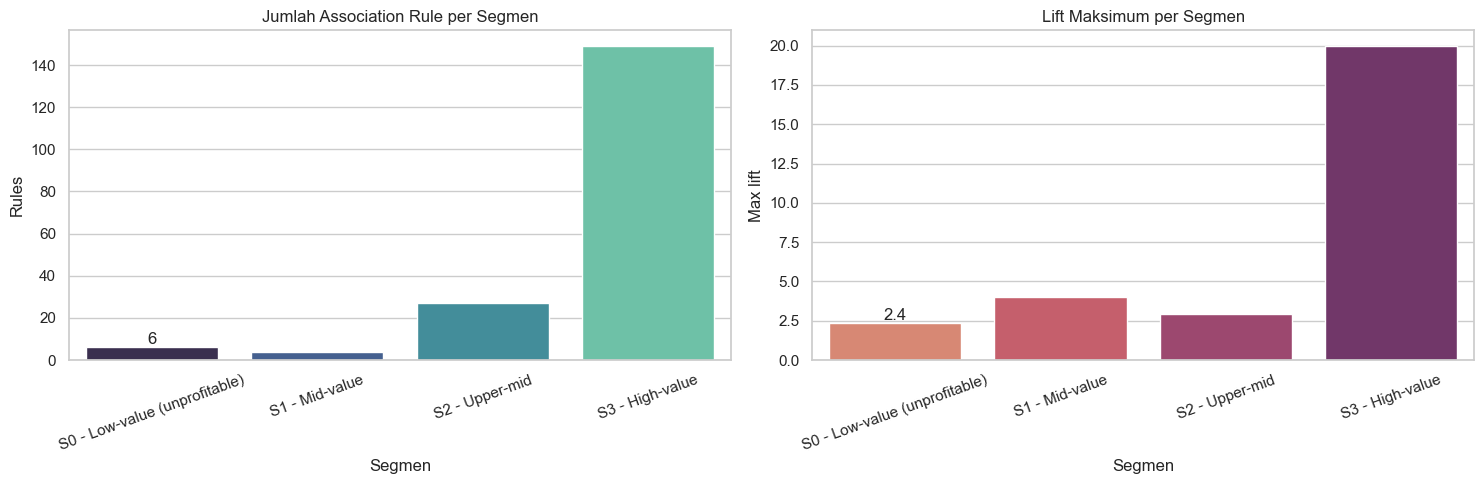

In [34]:
order_x = segment_summary['Segmen'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=segment_summary, x='Segmen', y='Rules', order=order_x,
            hue='Segmen', palette='mako', legend=False, ax=axes[0])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title('Jumlah Association Rule per Segmen')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=segment_summary, x='Segmen', y='Max lift', order=order_x,
            hue='Segmen', palette='flare', legend=False, ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt='%.1f')
axes[1].set_title('Lift Maksimum per Segmen')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

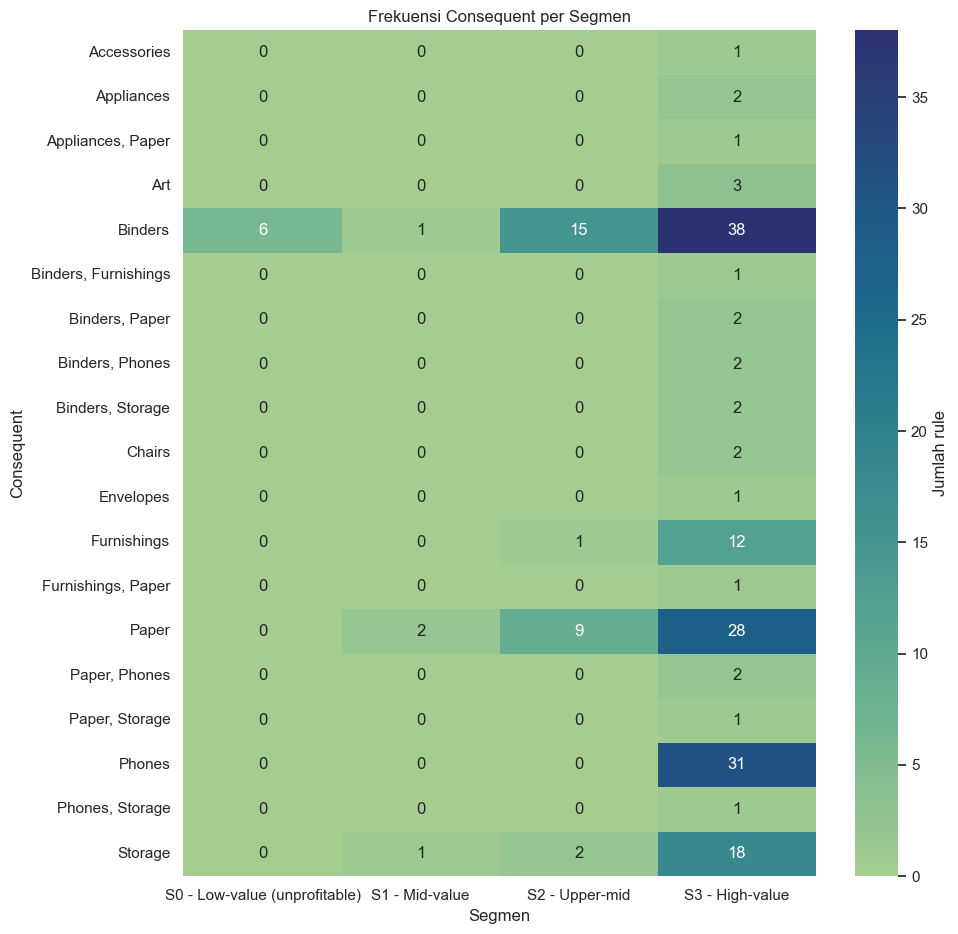

In [35]:
# Consequent dominan di tiap segmen
conseq = []
for seg, r_seg in segment_rules.items():
    for _, row in r_seg.iterrows():
        conseq.append({'Segmen': seg, 'Consequent': row['consequents']})
conseq_df = pd.DataFrame(conseq)

if not conseq_df.empty:
    pivot_seg = (conseq_df.groupby(['Consequent', 'Segmen']).size()
                 .unstack(fill_value=0)
                 .reindex(columns=order_x, fill_value=0))
    plt.figure(figsize=(10, max(4, 0.5 * len(pivot_seg))))
    sns.heatmap(pivot_seg, annot=True, fmt='d', cmap='crest', cbar_kws={'label': 'Jumlah rule'})
    plt.title('Frekuensi Consequent per Segmen')
    plt.tight_layout()
    plt.show()

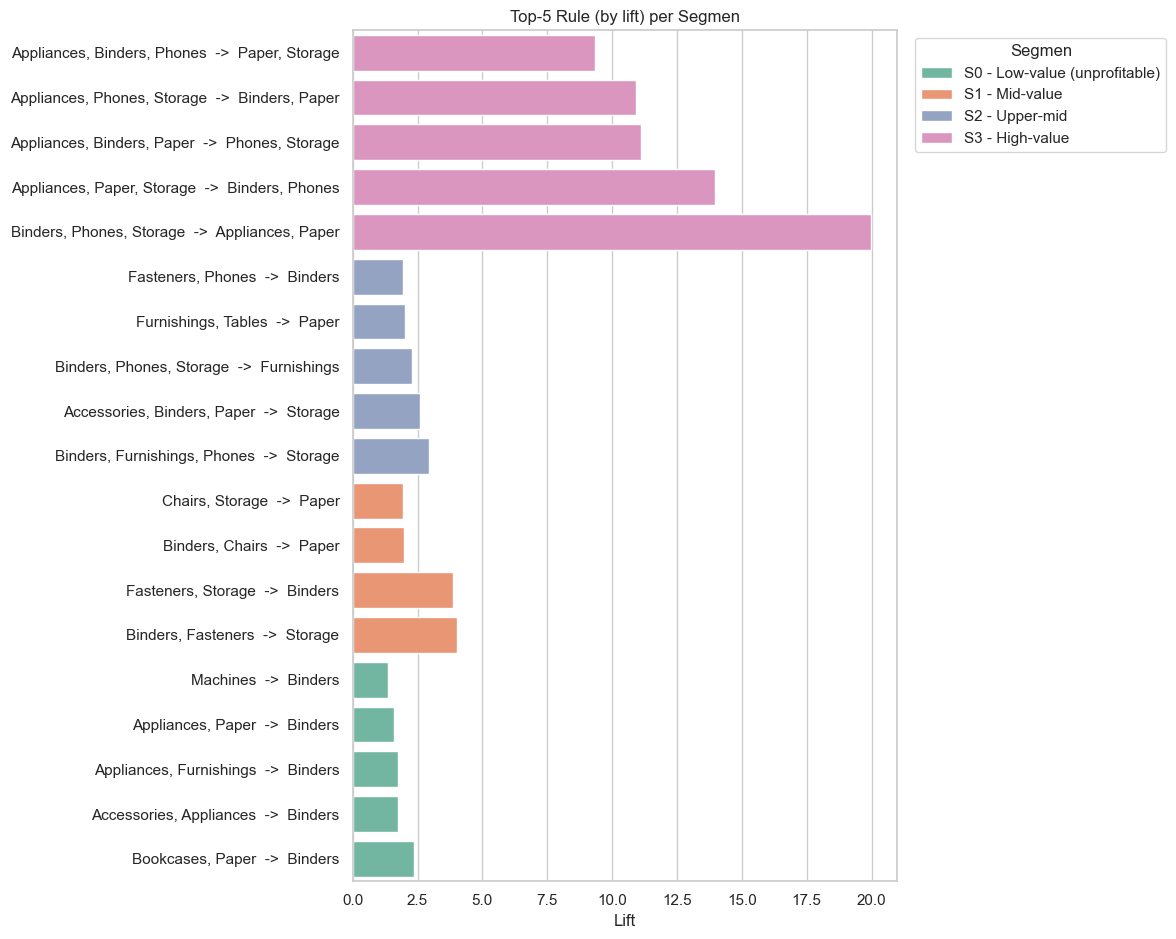

In [36]:
# Top-5 rule (by lift) tiap segmen dalam satu grafik
top_each = pd.concat(
    [r.head(5).assign(Segmen=seg) for seg, r in segment_rules.items() if len(r)],
    ignore_index=True)

plt.figure(figsize=(12, 0.45 * len(top_each) + 1))
ax = sns.barplot(data=top_each.iloc[::-1], y='rule', x='lift', hue='Segmen',
                 hue_order=order_x, palette='Set2', dodge=False)
ax.set_title('Top-5 Rule (by lift) per Segmen')
ax.set_xlabel('Lift')
ax.set_ylabel('')
plt.legend(title='Segmen', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8.4 Temuan segmentasi

- **Segmen high-value** (hanya 55 pelanggan, tapi keranjang besar & sering belanja) menghasilkan
  **paling banyak rule dengan lift sangat tinggi** — pola bundling di segmen ini paling kuat dan
  paling layak dijadikan target rekomendasi/paket produk.
- **Segmen unprofitable / low-value** hampir tidak punya pola *cross-sell* yang stabil; menaikkan
  nilai mereka lebih efektif lewat strategi lain (harga, akuisisi, pengurangan diskon) daripada bundling.
- **Paper** dan **Binders** tetap menjadi consequent dominan di hampir semua segmen — produk
  "perekat" lintas kategori.
- Kesimpulan: menambang rule **per segmen** memberi aksi yang lebih tepat sasaran dibanding hanya
  mengandalkan rule global di bagian 6-7. (Catatan: bagian 6 memakai `min_support=0.001` untuk
  menyorot rule terkuat; bagian 8 memakai `min_support=0.005` yang sama untuk semua segmen demi
  perbandingan yang adil.)

## 9. Interpretasi & Kesimpulan

**Association Rule Mining (global)**
- Pelanggan yang membeli **Chairs + Copiers** cenderung juga membeli **Paper** (confidence ~80%, lift ~3.4).
- Pelanggan yang membeli **Furnishings + Tables + Accessories** cenderung juga membeli **Paper** (confidence ~78%).
- Pelanggan yang membeli **Art + Fasteners + Phones** cenderung juga membeli **Binders** (confidence ~75%).
- **Paper** dan **Binders** adalah *consequent* yang paling sering muncul — keduanya cocok dijadikan
  produk rekomendasi / bundling lintas kategori.
- Apriori, FP-Growth, dan ECLAT memberi hasil identik; perbedaannya hanya pada strategi & kecepatan pencarian.

**Clustering + Rule-Based (bagian 8)**
- KMeans pada perilaku customer memisahkan pelanggan bernilai tinggi (high Sales & Profit) dari mayoritas
  pelanggan reguler; salah satu segmen bahkan rata-rata rugi.
- Dengan ambang batas yang sama, pola belanja antar segmen **tidak seragam**: segmen high-value
  (hanya 55 pelanggan) menghasilkan asosiasi produk yang jauh lebih kaya dan kuat, sedangkan
  segmen unprofitable nyaris tak punya pola cross-sell yang stabil.
- Rule per segmen ini melengkapi rule global di bagian 6-7 dengan aksi yang lebih tepat sasaran per tipe pelanggan.